# Лабораторная работа 3

**Сидимеков Дмитрий**

поиск ассоциативных правил в транзакциях интернет-магазина на наборе данных [Online Retail](https://archive.ics.uci.edu/dataset/352/online+retail)


## Данные

набор содержит транзакции британского онлайн-магазина подарков. Для поиска правил вида `если в корзине есть A, то стоит рекомендовать B` нужны не все признаки:

- `InvoiceNo` - идентификатор чека
- `Description` - название товара
- `Quantity`, `UnitPrice` - используем только для фильтрации возвратов и некорректных строк
- `InvoiceNo`, начинающийся с `C`, означает отмену заказа, такие строки удаляем

`CustomerID`, `Country`, `InvoiceDate` для базовой модели ассоциативных правил не нужны, потому что алгоритмы работают с множествами товаров внутри чеков.

In [6]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import math
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [7]:
DATA_PATH = Path("Online Retail.xlsx")
raw_df = pd.read_excel(DATA_PATH)
print(f"{raw_df.shape[0]:,} строк, {raw_df.shape[1]} столбцов")
raw_df.head()


541,909 строк, 8 столбцов


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
raw_summary = pd.DataFrame({
    "column": raw_df.columns,
    "type": [raw_df[col].dtype for col in raw_df.columns],
    "missing": [raw_df[col].isna().sum() for col in raw_df.columns],
    "unique": [raw_df[col].nunique(dropna=True) for col in raw_df.columns],
})
raw_summary


,column,type,missing,unique
0,InvoiceNo,object,0,25900
1,StockCode,object,0,4070
2,Description,object,1454,4223
3,Quantity,int64,0,722
4,InvoiceDate,datetime64[ns],0,23260
5,UnitPrice,float64,0,1630
6,CustomerID,float64,135080,4372
7,Country,object,0,38


## Предобработка

Для ассоциативных правил важен факт присутствия товара в чеке, а не количество одинаковых единиц. Поэтому каждый чек превратим в множество уникальных названий товаров. Корзины из одного уникального товара исключаем

Также удаляем служебные строки с доставкой, ручными корректировками и банковскими комиссиями (`POST`, `DOT`, `M`, `BANK CHARGES` и т.п.), потому что они не являются товарами


In [11]:
def normalize_item(value):
    """Приводит название товара к единому виду для корректного сравнения"""
    return " ".join(str(value).strip().upper().split())


clean_df = raw_df.dropna(subset=["InvoiceNo", "StockCode", "Description"]).copy()
clean_df["InvoiceNo"] = clean_df["InvoiceNo"].astype(str)

# Убираем отмененные заказы, возвраты и строки с нулевой/отрицательной ценой
clean_df = clean_df[~clean_df["InvoiceNo"].str.startswith("C")]
clean_df = clean_df[(clean_df["Quantity"] > 0) & (clean_df["UnitPrice"] > 0)]
clean_df["Item"] = clean_df["Description"].map(normalize_item)
clean_df["StockCodeText"] = clean_df["StockCode"].astype(str).str.upper().str.strip()

# Служебные коды не должны попадать в рекомендации как товары
service_stock_codes = {
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "AMAZONFEE",
    "B",
    "C2",
    "S",
    "D",
    "PADS",
}
service_rows = clean_df["StockCodeText"].isin(service_stock_codes).sum()
clean_df = clean_df[~clean_df["StockCodeText"].isin(service_stock_codes)]

basket_series = clean_df.groupby("InvoiceNo")["Item"].apply(
    lambda items: tuple(sorted(set(items)))
)
transactions = [frozenset(basket) for basket in basket_series if len(basket) >= 2]

transaction_lengths = pd.Series(
    [len(basket) for basket in transactions], name="basket_size"
)

prep_summary = pd.DataFrame(
    {
        "metric": [
            "Строк после очистки",
            "Удалено служебных строк",
            "Чеков после очистки",
            "Корзин с >= 2 товарами",
            "Уникальных товаров",
            "Средний размер корзины",
            "Медиана размеров корзины",
            "Максимальный размер корзины",
        ],
        "value": [
            len(clean_df),
            service_rows,
            clean_df["InvoiceNo"].nunique(),
            len(transactions),
            clean_df["Item"].nunique(),
            round(transaction_lengths.mean(), 2),
            int(transaction_lengths.median()),
            int(transaction_lengths.max()),
        ],
    }
)
prep_summary

,metric,value
0,Строк после очистки,527789.00
1,Удалено служебных строк,2315.00
2,Чеков после очистки,19773.00
3,Корзин с >= 2 товарами,18273.00
4,Уникальных товаров,3998.00
5,Средний размер корзины,28.21
6,Медиана размеров корзины,17.00
7,Максимальный размер корзины,1107.00


In [12]:
item_counts = Counter(item for basket in transactions for item in basket)
top_items = pd.DataFrame(item_counts.most_common(15), columns=["item", "transactions"])
top_items["support"] = top_items["transactions"] / len(transactions)
top_items


,item,transactions,support
0,WHITE HANGING HEART T-LIGHT HOLDER,2237,0.122421
1,JUMBO BAG RED RETROSPOT,2073,0.113446
2,REGENCY CAKESTAND 3 TIER,1965,0.107536
3,PARTY BUNTING,1670,0.091392
4,LUNCH BAG RED RETROSPOT,1563,0.085536
5,ASSORTED COLOUR BIRD ORNAMENT,1453,0.079516
6,SET OF 3 CAKE TINS PANTRY DESIGN,1376,0.075302
7,PACK OF 72 RETROSPOT CAKE CASES,1320,0.072238
8,LUNCH BAG SUKI DESIGN,1283,0.070213
9,LUNCH BAG BLACK SKULL.,1271,0.069556


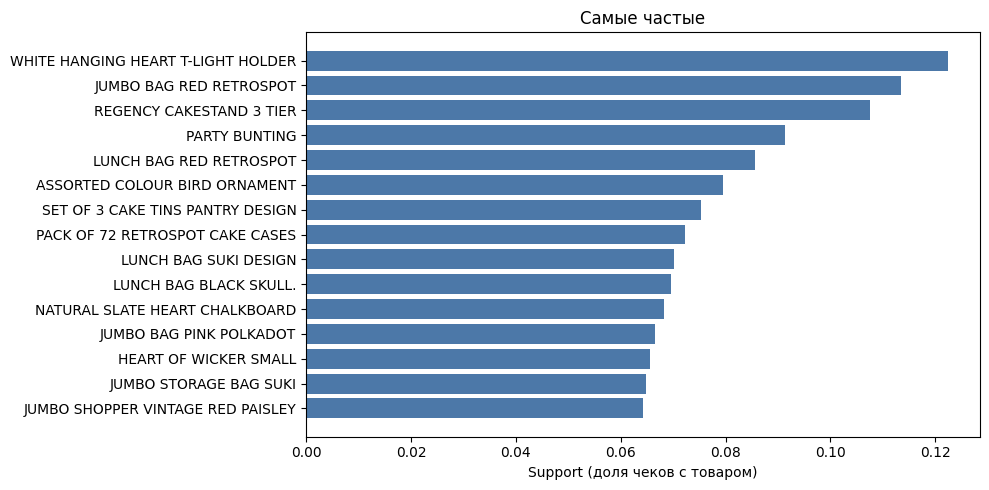

In [13]:
plt.figure(figsize=(10, 5))
plt.barh(top_items["item"][::-1], top_items["support"][::-1], color="#4C78A8")
plt.xlabel("Support (доля чеков с товаром)")
plt.title("Самые частые")
plt.tight_layout()
plt.show()


## Вспомогательные функции

`min_support` задаём абсолютным количеством чеков


In [ ]:
def support_to_count(min_support, n_transactions):
    """относительный или абсолютный min_support в минимальное число чеков"""
    if 0 < min_support < 1:
        return math.ceil(min_support * n_transactions)
    return int(min_support)


def itemset_to_text(itemset):
    """вывод набора товаров"""
    return " + ".join(sorted(itemset))


## Apriori

Идея Apriori: если набор товаров часто встречается, то все его поднаборы тоже должны быть частыми. Поэтому на каждом уровне `k` генерируем кандидатов только из частых наборов размера `k-1`, а затем пересчитываем поддержку кандидатов по корзинам.


In [ ]:
def generate_apriori_candidates(prev_itemsets, k):
    """Генерирует кандидаты размера k из частых наборов размера k-1"""
    prev_tuples = sorted(tuple(sorted(itemset)) for itemset in prev_itemsets)
    prev_lookup = {frozenset(itemset) for itemset in prev_tuples}
    candidates = set()

    for i in range(len(prev_tuples)):
        for j in range(i + 1, len(prev_tuples)):
            # Объединять можно только наборы с одинаковым префиксом длины k-2
            if prev_tuples[i][: k - 2] != prev_tuples[j][: k - 2]:
                break

            candidate = tuple(sorted(set(prev_tuples[i]) | set(prev_tuples[j])))
            if len(candidate) != k:
                continue

            # все поднаборы размера k-1 должны быть частыми
            all_subsets_are_frequent = all(
                frozenset(part) in prev_lookup
                for part in combinations(candidate, k - 1)
            )
            if all_subsets_are_frequent:
                candidates.add(frozenset(candidate))

    return candidates


def apriori(transactions, min_support=0.025, max_len=None, verbose=False):
    """
    Реализация Apriori

    Возвращает:
    - frequent_itemsets: dict[frozenset, int] с абсолютными supp
    - level_stats: DataFrame со статистикой по уровням
    """
    n_transactions = len(transactions)
    min_count = support_to_count(min_support, n_transactions)

    singleton_counts = Counter(item for basket in transactions for item in basket)
    current_level = {
        frozenset([item]): count
        for item, count in singleton_counts.items()
        if count >= min_count
    }

    frequent_itemsets = dict(current_level)
    level_stats = [{
        "k": 1,
        "candidates": len(singleton_counts),
        "frequent_itemsets": len(current_level),
    }]

    # После первого уровня можно удалить из корзин все заведомо редкие товары.
    frequent_single_items = {next(iter(itemset)) for itemset in current_level}
    filtered_transactions = [
        tuple(sorted(item for item in basket if item in frequent_single_items))
        for basket in transactions
    ]

    k = 2
    while current_level and (max_len is None or k <= max_len):
        candidates = generate_apriori_candidates(current_level.keys(), k)
        if not candidates:
            break

        candidate_counts = Counter()
        for basket in filtered_transactions:
            if len(basket) < k:
                continue
            for combo in combinations(basket, k):
                itemset = frozenset(combo)
                if itemset in candidates:
                    candidate_counts[itemset] += 1

        current_level = {
            itemset: count
            for itemset, count in candidate_counts.items()
            if count >= min_count
        }
        frequent_itemsets.update(current_level)

        level_stats.append({
            "k": k,
            "candidates": len(candidates),
            "frequent_itemsets": len(current_level),
        })

        if verbose:
            print(f"Apriori k={k}: candidates={len(candidates):,}, frequent={len(current_level):,}")

        k += 1

    return frequent_itemsets, pd.DataFrame(level_stats)


## FP-Growth

FP-Growth строит FP-дерево: общие префиксы транзакций хранятся один раз с увеличенным счетчиком. Затем алгоритм рекурсивно строит условные деревья для каждого товара и восстанавливает частые наборы без явной генерации всех кандидатов, как в Apriori


In [ ]:
class FPNode:
    """Узел FP-дерева"""

    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None


def build_fp_tree(weighted_transactions, min_count):
    """
    Строит FP-дерево по взвешенным транзакциям
    weighted_transactions: iterable[(items, weight)]
    """
    item_counts = Counter()
    for transaction, weight in weighted_transactions:
        for item in transaction:
            item_counts[item] += weight

    frequent_items = {
        item: count
        for item, count in item_counts.items()
        if count >= min_count
    }
    if not frequent_items:
        return None, {}, {}

    # Внутри транзакций товары упорядочиваются по убыванию поддержки
    order = {
        item: rank
        for rank, item in enumerate(sorted(frequent_items, key=lambda x: (-frequent_items[x], x)))
    }

    root = FPNode(item=None, count=0, parent=None)
    header = {item: [frequent_items[item], None] for item in frequent_items}

    for transaction, weight in weighted_transactions:
        ordered_items = sorted(
            (item for item in transaction if item in frequent_items),
            key=lambda item: order[item],
        )
        if not ordered_items:
            continue

        node = root
        for item in ordered_items:
            child = node.children.get(item)
            if child is None:
                child = FPNode(item=item, count=0, parent=node)
                node.children[item] = child

                # Header table связывает все узлы с одинаковым товаром в цепочку
                if header[item][1] is None:
                    header[item][1] = child
                else:
                    current = header[item][1]
                    while current.link is not None:
                        current = current.link
                    current.link = child

            child.count += weight
            node = child

    return root, header, frequent_items


def ascend_fp_path(node):
    """Возвращает путь от корня до родителя данного узла"""
    path = []
    current = node.parent
    while current is not None and current.item is not None:
        path.append(current.item)
        current = current.parent
    path.reverse()
    return path


def mine_fp_tree(header, min_count, suffix, frequent_itemsets):
    """Рекурсивно извлекает частые наборы из FP-дерева"""
    # Начинаем с наименее частых товаров: так условные деревья обычно меньше.
    for item in sorted(header, key=lambda x: (header[x][0], x)):
        new_itemset = frozenset(set(suffix) | {item})
        frequent_itemsets[new_itemset] = header[item][0]

        conditional_patterns = []
        node = header[item][1]
        while node is not None:
            path = ascend_fp_path(node)
            if path:
                conditional_patterns.append((path, node.count))
            node = node.link

        _, conditional_header, _ = build_fp_tree(conditional_patterns, min_count)
        if conditional_header:
            mine_fp_tree(conditional_header, min_count, new_itemset, frequent_itemsets)


def fp_growth(transactions, min_support=0.025):
    """
    Реализация FP-Growth

    Возвращает:
    - frequent_itemsets: dict[frozenset, int] с абсолютными поддержками
    - level_stats: DataFrame с количеством частых наборов по размерам
    """
    min_count = support_to_count(min_support, len(transactions))
    weighted_transactions = [(list(transaction), 1) for transaction in transactions]

    _, header, _ = build_fp_tree(weighted_transactions, min_count)
    frequent_itemsets = {}
    if header:
        mine_fp_tree(header, min_count, frozenset(), frequent_itemsets)

    level_counts = Counter(len(itemset) for itemset in frequent_itemsets)
    level_stats = pd.DataFrame(
        [{"k": k, "frequent_itemsets": level_counts[k]} for k in sorted(level_counts)]
    )
    return frequent_itemsets, level_stats


## Обучение и сравнение времени

Порог `MIN_SUPPORT = 0.025` означает, что набор должен встречаться минимум примерно в 2.5% чеков. Для более детального поиска можно уменьшать порог, но время Apriori растет намного быстрее


In [10]:
MIN_SUPPORT = 0.025
MIN_CONFIDENCE = 0.45
min_support_count = support_to_count(MIN_SUPPORT, len(transactions))
print(f"MIN_SUPPORT={MIN_SUPPORT} -> минимум {min_support_count} чеков из {len(transactions):,}")
print(f"MIN_CONFIDENCE={MIN_CONFIDENCE}")


MIN_SUPPORT=0.025 -> минимум 457 чеков из 18,273
MIN_CONFIDENCE=0.45


In [11]:
timings = []

start = time.perf_counter()
apriori_itemsets, apriori_levels = apriori(transactions, min_support=MIN_SUPPORT, verbose=True)
apriori_time = time.perf_counter() - start
timings.append({
    "algorithm": "Apriori",
    "time_sec": apriori_time,
    "frequent_itemsets": len(apriori_itemsets),
})

start = time.perf_counter()
fpgrowth_itemsets, fpgrowth_levels = fp_growth(transactions, min_support=MIN_SUPPORT)
fpgrowth_time = time.perf_counter() - start
timings.append({
    "algorithm": "FP-Growth",
    "time_sec": fpgrowth_time,
    "frequent_itemsets": len(fpgrowth_itemsets),
})

timing_df = pd.DataFrame(timings)
timing_df["time_sec"] = timing_df["time_sec"].round(4)

print("Частые наборы совпадают:", apriori_itemsets == fpgrowth_itemsets)
display(timing_df)
print("\nУровни Apriori:")
display(apriori_levels)
print("\nУровни FP-Growth:")
display(fpgrowth_levels)


Apriori k=2: candidates=24,090, frequent=48


Apriori k=3: candidates=23, frequent=1


Частые наборы совпадают: True


,algorithm,time_sec,frequent_itemsets
0,Apriori,9.3602,269
1,FP-Growth,3.5894,269



Уровни Apriori:


,k,candidates,frequent_itemsets
0,1,3991,220
1,2,24090,48
2,3,23,1



Уровни FP-Growth:


,k,frequent_itemsets
0,1,220
1,2,48
2,3,1


## Ассоциативные правила

Для частого набора `A ∪ B` строим правила `A -> B` и считаем

- `support(A ∪ B)` - доля чеков, где есть обе части правила
- `confidence(A -> B) = support(A ∪ B) / support(A)`
- `lift(A -> B) = confidence(A -> B) / support(B)`

`lift > 1` означает, что правая часть встречается вместе с левой чаще, чем ожидалось бы при независимости


In [ ]:
def association_rules(frequent_itemsets, n_transactions, min_confidence=0.45):
    """Генерирует правила из словаря частых наборов"""
    rules = []

    for itemset, itemset_count in frequent_itemsets.items():
        if len(itemset) < 2:
            continue

        items = tuple(sorted(itemset))
        for antecedent_size in range(1, len(items)):
            for antecedent_tuple in combinations(items, antecedent_size):
                antecedent = frozenset(antecedent_tuple)
                consequent = itemset - antecedent

                antecedent_count = frequent_itemsets.get(antecedent)
                consequent_count = frequent_itemsets.get(consequent)
                if antecedent_count is None or consequent_count is None:
                    continue

                confidence = itemset_count / antecedent_count
                if confidence < min_confidence:
                    continue

                support = itemset_count / n_transactions
                consequent_support = consequent_count / n_transactions
                lift = confidence / consequent_support

                rules.append({
                    "antecedent": tuple(sorted(antecedent)),
                    "consequent": tuple(sorted(consequent)),
                    "support": support,
                    "support_count": itemset_count,
                    "confidence": confidence,
                    "lift": lift,
                })

    rules_df = pd.DataFrame(rules)
    if rules_df.empty:
        return rules_df

    return rules_df.sort_values(
        by=["confidence", "lift", "support"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


rules = association_rules(fpgrowth_itemsets, len(transactions), min_confidence=MIN_CONFIDENCE)
print(f"Получено правил: {len(rules)}")

rules_view = rules.copy()
rules_view["antecedent"] = rules_view["antecedent"].map(itemset_to_text)
rules_view["consequent"] = rules_view["consequent"].map(itemset_to_text)
rules_view[["antecedent", "consequent", "support", "support_count", "confidence", "lift"]].head(15)


Получено правил: 58


,antecedent,consequent,support,support_count,confidence,lift
0,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.029607,541,0.904682,16.319111
1,GREEN REGENCY TEACUP AND SAUCER + PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029607,541,0.856013,14.728738
2,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.034587,632,0.831579,15.000436
3,PINK REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.032726,598,0.786842,13.538574
4,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.041974,767,0.757157,13.027805
5,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.041974,767,0.722222,13.027805
6,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.029880,546,0.721268,14.451462
7,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER,0.029607,541,0.711842,16.958919
8,GREEN REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.029607,541,0.705346,16.958919
9,CHARLOTTE BAG PINK POLKADOT,RED RETROSPOT CHARLOTTE BAG,0.028567,522,0.703504,12.456521


## Проверка правил как рекомендаций к корзине

Функция ниже принимает текущую корзину, ищет правила, у которых левая часть полностью содержится в корзине, и возвращает товары из правой части как рекомендации. Если один товар найден по нескольким правилам, оставляем самое сильное совпадение по `confidence`, затем по `lift`


In [ ]:
def recommend_from_basket(basket, rules_df, top_n=10):
    """
    Возвращает рекомендации по текущей корзине

    basket: список названий товаров. Названия нормализуются так же, как в обучающей выборке
    rules_df: таблица правил из association_rules()
    """
    basket_set = {normalize_item(item) for item in basket}
    recommendations = []

    for _, rule in rules_df.iterrows():
        antecedent = set(rule["antecedent"])
        consequent = set(rule["consequent"])

        if not antecedent.issubset(basket_set):
            continue

        new_items = consequent - basket_set
        for item in new_items:
            recommendations.append(
                {
                    "recommendation": item,
                    "confidence": rule["confidence"],
                    "lift": rule["lift"],
                    "support": rule["support"],
                    "support_count": rule["support_count"],
                    "matched_rule": f"{itemset_to_text(rule['antecedent'])} -> {itemset_to_text(rule['consequent'])}",
                }
            )

    if not recommendations:
        return pd.DataFrame(
            columns=[
                "recommendation",
                "confidence",
                "lift",
                "support",
                "support_count",
                "matched_rule",
            ]
        )

    recs = pd.DataFrame(recommendations).sort_values(
        by=["confidence", "lift", "support"],
        ascending=[False, False, False],
    )

    # Одна рекомендация может появиться из нескольких правил; оставляем лучшее правило
    recs = recs.groupby("recommendation", as_index=False, sort=False).agg(
        {
            "confidence": "first",
            "lift": "first",
            "support": "first",
            "support_count": "first",
            "matched_rule": "first",
        }
    )

    return (
        recs.sort_values(
            by=["confidence", "lift", "support"],
            ascending=[False, False, False],
        )
        .head(top_n)
        .reset_index(drop=True)
    )

In [15]:
example_basket = [
    "PINK REGENCY TEACUP AND SAUCER",
    "ROSES REGENCY TEACUP AND SAUCER",
]

print("Текущая корзина:")
for item in example_basket:
    print("-", item)

recommend_from_basket(example_basket, rules, top_n=10)


Текущая корзина:
- PINK REGENCY TEACUP AND SAUCER
- ROSES REGENCY TEACUP AND SAUCER


,recommendation,confidence,lift,support,support_count,matched_rule
0,GREEN REGENCY TEACUP AND SAUCER,0.904682,16.319111,0.029607,541,PINK REGENCY TEACUP AND SAUCER + ROSES REGENCY TEACUP AND SAUCER -> GREEN REGENCY TEACUP AND SAUCER
1,REGENCY CAKESTAND 3 TIER,0.494350,4.597080,0.028731,525,ROSES REGENCY TEACUP AND SAUCER -> REGENCY CAKESTAND 3 TIER


In [ ]:
# Еще один пример: можно подставить любой список товаров из таблицы top_items
example_basket_2 = [
    "CHARLOTTE BAG PINK POLKADOT",
]

print("Текущая корзина:")
for item in example_basket_2:
    print("-", item)

recommend_from_basket(example_basket_2, rules, top_n=10)


Текущая корзина:
- CHARLOTTE BAG PINK POLKADOT


,recommendation,confidence,lift,support,support_count,matched_rule
0,RED RETROSPOT CHARLOTTE BAG,0.703504,12.456521,0.028567,522,CHARLOTTE BAG PINK POLKADOT -> RED RETROSPOT CHARLOTTE BAG


## Выводы

- Apriori и FP-Growth нашли одинаковые частые наборы при одном и том же `min_support`, что проверяет корректность реализаций друг через друга
- FP-Growth обычно быстрее на этом наборе, потому что не генерирует большое число кандидатов-кандидатных пар и троек явно
- Полученные правила можно использовать как простую рекомендательную функцию. текущая корзина сопоставляется с левой частью правил, а правая часть становится списком рекомендуемых товаров
